## How to Scrape Indonesian App StartUp on Google Playstore

In [1]:
from google_play_scraper import Sort, reviews_all
import pandas as pd

# Function to scrape reviews
def scrape_reviews(app_id):
    reviews = reviews_all(
        app_id,
        sleep_milliseconds=0,  # Time to sleep between requests
        lang='id',  # Language of reviews
        country='id',  # Country of reviews
        sort=Sort.NEWEST  # Sort reviews by newest
    )
    
    # Extract relevant fields
    data = {
        'created_at': [review['at'] for review in reviews],
        'score': [review['score'] for review in reviews],
        'content': [review['content'] for review in reviews],
        'thumbsUpCount': [review['thumbsUpCount'] for review in reviews]
    }
    
    # Create DataFrame
    df_reviews = pd.DataFrame(data)
    return df_reviews

# Example usage
app_id = 'com.pizzahut.phd'  # Replace with the actual app ID
df_reviews = scrape_reviews(app_id)
df_reviews.to_csv('phd_reviews.csv', index=True)
print(df_reviews)

               created_at  score  \
0     2026-03-29 21:22:53      5   
1     2026-03-29 18:53:17      4   
2     2026-03-28 19:29:59      1   
3     2026-03-28 14:45:21      5   
4     2026-03-28 14:26:31      5   
...                   ...    ...   
20848 2017-06-03 18:07:56      5   
20849 2017-06-03 17:34:43      5   
20850 2017-06-03 14:48:02      5   
20851 2017-06-03 10:58:29      5   
20852 2017-06-03 09:34:00      1   

                                                 content  thumbsUpCount  
0      pelayanan staff cabang veteran 2sangat baik, m...              0  
1      aplikasinya bagus,tapi kenapa alamat rumah say...              0  
2      restoran taik nya ni.. gak pernah gak bermasal...              0  
3                                        tepatnya nyaman              0  
4      aplikasi ini bagus buat yang mesen makanan tet...              0  
...                                                  ...            ...  
20848                                          Go

## Data Analysis Examples on Indonesia StartUp Apps Reviews

### Read dataset

In [3]:
import pandas as pd

# Read the CSV file
# df_blibli = pd.read_csv('/kaggle/input/reviews-of-indonesian-app-startups-on-playstore/blibli.csv')
df_phd = pd.read_csv('D:/PBA/Tugas 2/phd_reviews.csv')

# Display the first few rows of the dataframe
df_phd.head()

,Unnamed: 0,created_at,score,content,thumbsUpCount
0,0,2026-03-29 21:22:53,5,"pelayanan staff cabang veteran 2sangat baik, m...",0
1,1,2026-03-29 18:53:17,4,"aplikasinya bagus,tapi kenapa alamat rumah say...",0
2,2,2026-03-28 19:29:59,1,restoran taik nya ni.. gak pernah gak bermasal...,0
3,3,2026-03-28 14:45:21,5,tepatnya nyaman,0
4,4,2026-03-28 14:26:31,5,aplikasi ini bagus buat yang mesen makanan tet...,0


### Statistik Deskriptif

C:\Users\Frans\AppData\Local\Temp\ipykernel_5536\2853549000.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')


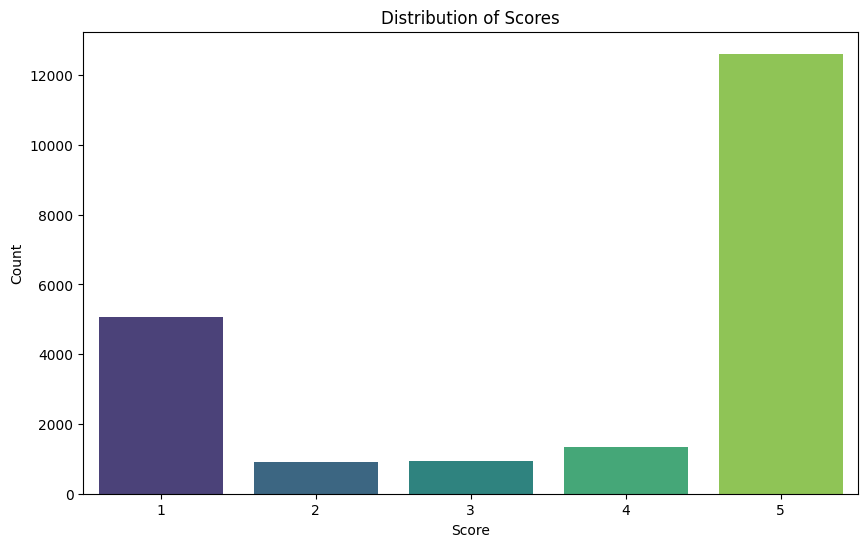

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analisis deskriptif untuk kolom 'score'
score_counts = df_phd['score'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

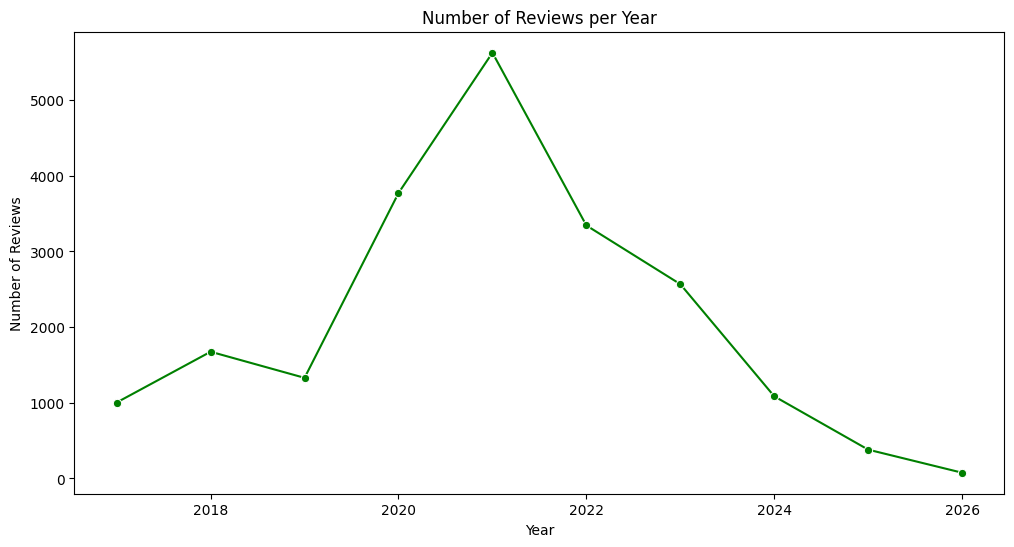

In [5]:
# Analisis deskriptif untuk kolom 'created_at'
df_phd['created_at'] = pd.to_datetime(df_phd['created_at'])
df_phd['year'] = df_phd['created_at'].dt.year
year_counts = df_phd['year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

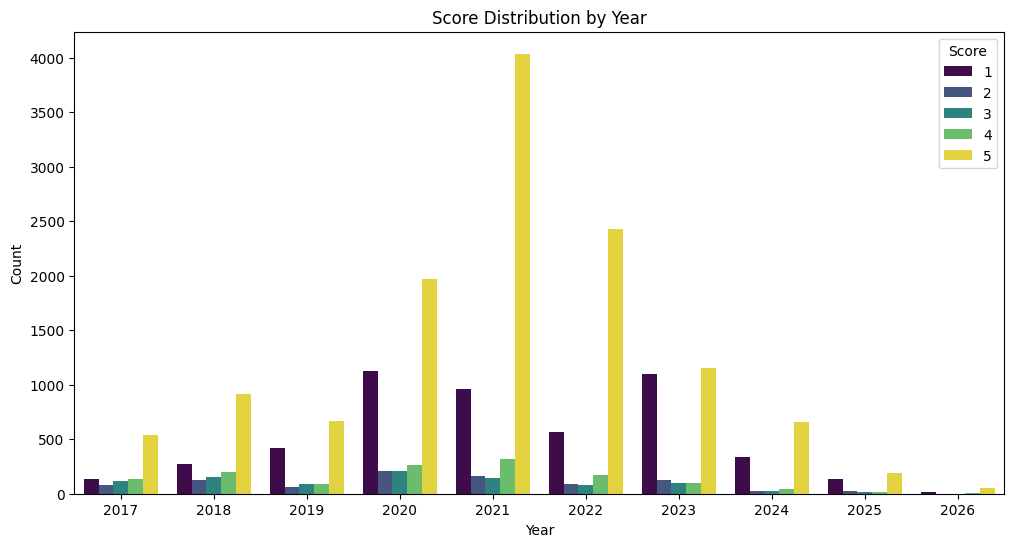

In [6]:
# Cross tabulasi antara 'year' dan 'score'
plt.figure(figsize=(12, 6))
sns.countplot(x='year', hue='score', data=df_phd, palette='viridis')
plt.title('Score Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Score')
plt.show()

### Wordcloud

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Get the list of stopwords in Indonesian
stop_words = set(stopwords.words('indonesian'))

# Function to remove stopwords from a given text
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Filter positive and negative reviews
positive_reviews = df_phd[df_phd['score'] >= 4]['content'].dropna()
negative_reviews = df_phd[df_phd['score'] <= 3]['content'].dropna()

# Combine all positive and negative reviews into single strings
positive_text = ' '.join(positive_reviews)
negative_text = ' '.join(negative_reviews)

# Remove stopwords from the combined texts
positive_text = remove_stopwords(positive_text)
negative_text = remove_stopwords(negative_text)

# Generate word clouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Frans\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


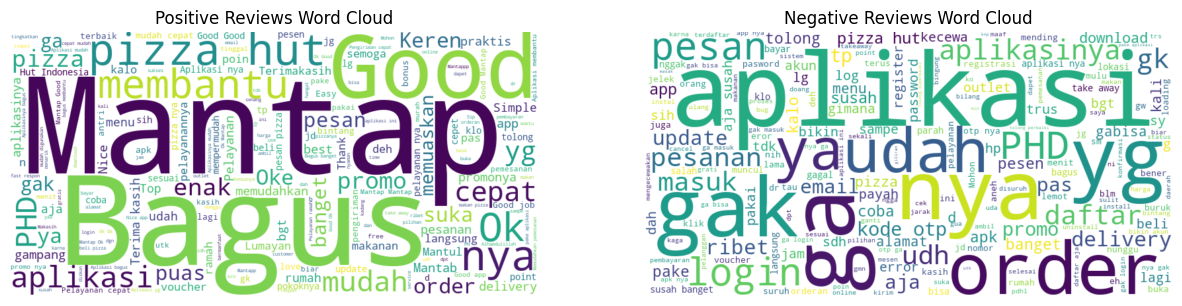

In [8]:
# Plot the word clouds
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Reviews Word Cloud')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Reviews Word Cloud')
plt.axis('off')

plt.show()

### Regex-based pattern analysis
Mengelompokkan review ke beberapa tema menggunakan ekspresi reguler membantu melihat cepat area keluhan atau pujian spesifik tanpa harus membaca seluruh teks.

In [11]:
import re

regex_patterns = {
    'payment_issue': r'\b(?:bayar|payment)\w*(?:\s+\w+){0,3}\s*(?:error|gagal|ditolak)',
    'delivery_issue': r'\b(?:kirim|antar|driver|kurir)\w*',
    'promo_mentions': r'\b(?:promo|diskon|voucher)\w*',
    'app_performance': r'\b(?:error|bug|lemot|hang|crash)\b',
    'service_quality': r'\b(?:layan|service|cs|customer)\w*'
}

content_series = df_phd['content'].fillna('')
regex_summary = []
sample_texts = {}

for label, pattern in regex_patterns.items():
    matches = content_series.str.contains(pattern, case=False, regex=True)
    df_phd[f'regex_{label}'] = matches
    regex_summary.append({
        'pattern_label': label,
        'regex': pattern,
        'match_count': int(matches.sum()),
        'share_%': round(matches.mean() * 100, 2)
    })
    sample_texts[label] = df_phd.loc[matches, 'content'].head(3).tolist()

regex_summary_df = pd.DataFrame(regex_summary).sort_values('match_count', ascending=False)
display(regex_summary_df)

for label, samples in sample_texts.items():
    print(f"\nExamples for {label} (showing {len(samples)}):")
    for text in samples:
        snippet = text.replace('\n', ' ')[:200]
        suffix = '...' if len(text) > 200 else ''
        print(f"- {snippet}{suffix}")

,pattern_label,regex,match_count,share_%
2,promo_mentions,\b(?:promo|diskon|voucher)\w*,1336,6.41
3,app_performance,\b(?:error|bug|lemot|hang|crash)\b,552,2.65
1,delivery_issue,\b(?:kirim|antar|driver|kurir)\w*,521,2.50
4,service_quality,\b(?:layan|service|cs|customer)\w*,395,1.89
0,payment_issue,"\b(?:bayar|payment)\w*(?:\s+\w+){0,3}\s*(?:err...",7,0.03



Examples for payment_issue (showing 3):
- APLIKASI CACAT SEKALI SUPER LEMOT BANGET ,UDAH LEMOT PAS MAU BAYAR MALAH GAGAL. SANGAT TIDAK BERGUNA APLIKASINYA. JELEJ BANGET LEMOT BGT
- Bayar pakai gopay gagal terus..
- Tiap mau bayar selalu error, mana udh pake voucher, pasti nanti vouchernya ilang. Udah diupdate juga padahal

Examples for delivery_issue (showing 3):
- aplikasinya kurang nyaman untuk digunakan, ketika mengklik promo harus mengulang di klik beberapa kali agar merespon dan masuk laman yang ingin dituju. lalu untuk pesan selalu harus mengisi alamat tuj...
- saya dari tadi login ga bisa bisa. tolong perbaiki aplikasinya. disuruh kirim otp, tapi tidak ada otp masuk
- alamat hrs masukin ulang terus meski uda beli bbrp kali. repot kali. trs harga akhir ga sesuai. dengan total harga tercantum. sy ada screenshot layarnya. sayang ga bisa kirim foto disini

Examples for promo_mentions (showing 3):
- sangat memudahkan pesan pizza lewat aplikasi pizza hut Indonesia dan cukup menguntun